In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelBinarizer
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression , Lasso ,Ridge
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,\
confusion_matrix,classification_report,balanced_accuracy_score,roc_auc_score,roc_curve
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB,ComplementNB,MultinomialNB,CategoricalNB,BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.tree import plot_tree
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest,chi2,f_classif,f_oneway,f_regression
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB,ComplementNB,MultinomialNB,CategoricalNB,BernoulliNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import  RandomForestClassifier
from sklearn.ensemble import  ExtraTreesClassifier
from sklearn.ensemble import  BaggingClassifier
from sklearn.ensemble import  AdaBoostClassifier
from sklearn.ensemble import  GradientBoostingClassifier
from sklearn.experimental import enable_hist_gradient_boosting 
from sklearn.ensemble import  HistGradientBoostingClassifier
import xgboost as xgb
from xgboost import  XGBClassifier
from catboost import  CatBoostClassifier
import lightgbm as lgb
from lightgbm import  LGBMClassifier
from sklearn.ensemble import  StackingClassifier
from sklearn.ensemble import  RandomForestClassifier
from sklearn.ensemble import  GradientBoostingClassifier
from sklearn.linear_model import  LogisticRegression
from xgboost import  XGBClassifier
from catboost import  CatBoostClassifier
from lightgbm import  LGBMClassifier
from tqdm import tqdm
from sklearn.metrics import average_precision_score, precision_recall_curve
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    roc_auc_score,roc_curve,
    precision_recall_curve,average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score, make_scorer
from sklearn.metrics import ConfusionMatrixDisplay
import math
import plotly.express as px

In [67]:
df=pd.read_csv(r'D:\saifproject\saif datascience\Data/diabetes prediction.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Male,22.0,0.0,0.0,never,36.29,6.1,100.0,0
1,Female,29.0,0.0,0.0,No Info,27.32,4.0,140.0,0
2,Female,4.0,0.0,0.0,No Info,13.29,6.0,85.0,0
3,Male,28.0,0.0,0.0,former,31.58,4.8,130.0,0
4,Female,62.0,0.0,0.0,current,27.32,3.5,159.0,0


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               16924 non-null  object 
 1   age                  16960 non-null  float64
 2   hypertension         16951 non-null  float64
 3   heart_disease        16922 non-null  float64
 4   smoking_history      16935 non-null  object 
 5   bmi                  16940 non-null  float64
 6   HbA1c_level          16949 non-null  float64
 7   blood_glucose_level  16967 non-null  float64
 8   diabetes             17000 non-null  int64  
dtypes: float64(6), int64(1), object(2)
memory usage: 1.2+ MB


In [69]:
df.isna().sum().sort_values(ascending=False)

heart_disease          78
gender                 76
smoking_history        65
bmi                    60
HbA1c_level            51
hypertension           49
age                    40
blood_glucose_level    33
diabetes                0
dtype: int64

In [70]:
df['smoking_history'].value_counts()

smoking_history
never          6320
No Info        4586
former         2311
current        1723
not current    1219
ever            776
Name: count, dtype: int64

In [71]:
df['smoking_history'].value_counts()

smoking_history
never          6320
No Info        4586
former         2311
current        1723
not current    1219
ever            776
Name: count, dtype: int64

In [72]:
def recategorize_smoking(smoking_status):
    if smoking_status in ['never', 'No Info']:
        return 'non-smoker'
    elif smoking_status == 'current':
        return 'current'
    elif smoking_status in ['ever', 'former', 'not current']:
        return 'past_smoker'
df['smoking_history'] = df['smoking_history'].apply(recategorize_smoking)
print(df['smoking_history'].value_counts())

smoking_history
non-smoker     10906
past_smoker     4306
current         1723
Name: count, dtype: int64


In [73]:
df.isna().sum().sort_values(ascending=False)

heart_disease          78
gender                 76
smoking_history        65
bmi                    60
HbA1c_level            51
hypertension           49
age                    40
blood_glucose_level    33
diabetes                0
dtype: int64

In [74]:
df['gender'].value_counts()

gender
Female    9457
Male      7465
Other        2
Name: count, dtype: int64

In [75]:
df["gender"].replace("Other", np.nan, inplace=True)

D:\Temp\ipykernel_13124\2889083575.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["gender"].replace("Other", np.nan, inplace=True)


In [76]:
df.isna().sum().sort_values(ascending=False)

gender                 78
heart_disease          78
smoking_history        65
bmi                    60
HbA1c_level            51
hypertension           49
age                    40
blood_glucose_level    33
diabetes                0
dtype: int64

In [77]:
df['bmi'].value_counts()

bmi
27.32    3760
29.29      22
29.40      21
25.60      21
26.95      20
         ... 
46.48       1
44.93       1
57.70       1
46.03       1
47.11       1
Name: count, Length: 3335, dtype: int64

In [78]:
df['HbA1c_level'].value_counts()

HbA1c_level
5.7    1428
6.6    1411
5.8    1370
6.5    1354
6.0    1351
6.1    1343
6.2    1311
4.8     742
3.5     708
4.5     687
4.0     682
5.0     667
8.2     661
8.8     661
9.0     654
7.5     643
6.8     642
7.0     634
Name: count, dtype: int64

In [79]:
df['hypertension'].value_counts()

hypertension
0.0    14380
1.0     2571
Name: count, dtype: int64

In [80]:
df['blood_glucose_level'].value_counts()

blood_glucose_level
145.0    1335
159.0    1332
160.0    1309
126.0    1309
130.0    1305
200.0    1299
140.0    1254
155.0    1253
280.0     729
300.0     674
100.0     669
158.0     665
80.0      665
90.0      651
85.0      644
240.0     636
260.0     635
220.0     603
Name: count, dtype: int64

In [81]:
df['diabetes'].value_counts()

diabetes
0    8500
1    8500
Name: count, dtype: int64

In [82]:
df['heart_disease'].value_counts()

heart_disease
0.0    15408
1.0     1514
Name: count, dtype: int64

In [83]:
df.isna().sum().sort_values(ascending=False)

gender                 78
heart_disease          78
smoking_history        65
bmi                    60
HbA1c_level            51
hypertension           49
age                    40
blood_glucose_level    33
diabetes                0
dtype: int64

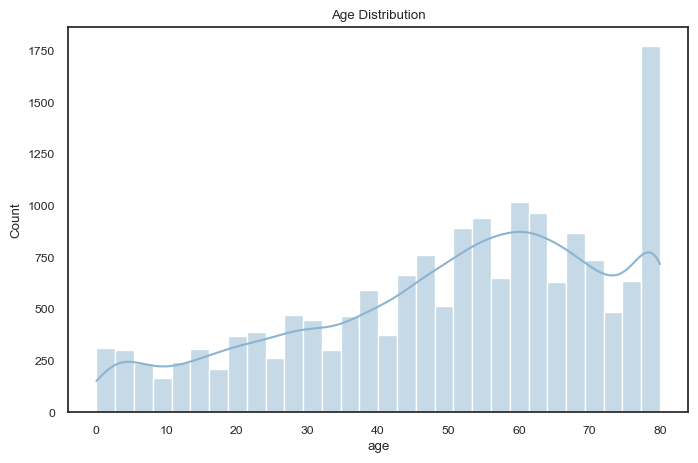

In [84]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'hypertension'}>,
        <Axes: title={'center': 'heart_disease'}>],
       [<Axes: title={'center': 'bmi'}>,
        <Axes: title={'center': 'HbA1c_level'}>,
        <Axes: title={'center': 'blood_glucose_level'}>],
       [<Axes: title={'center': 'diabetes'}>, <Axes: >, <Axes: >]],
      dtype=object)

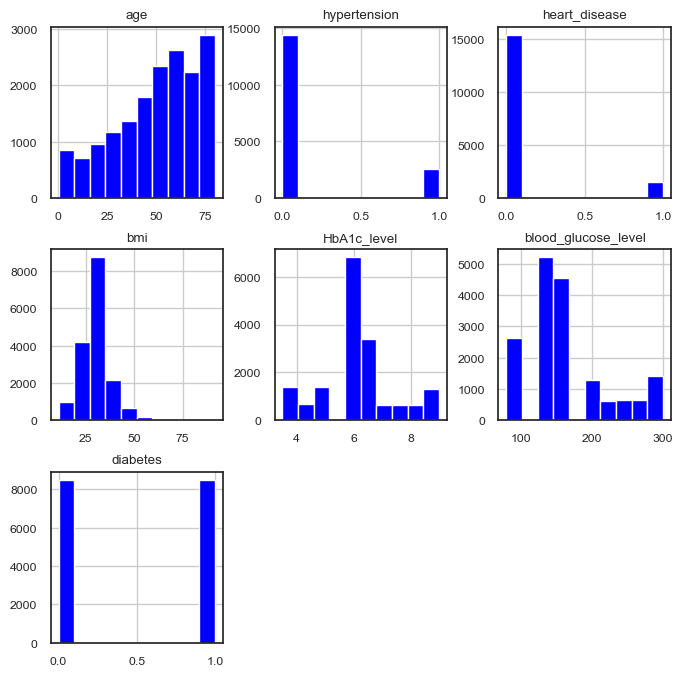

In [85]:
df.hist(figsize=(8,8), color='blue')

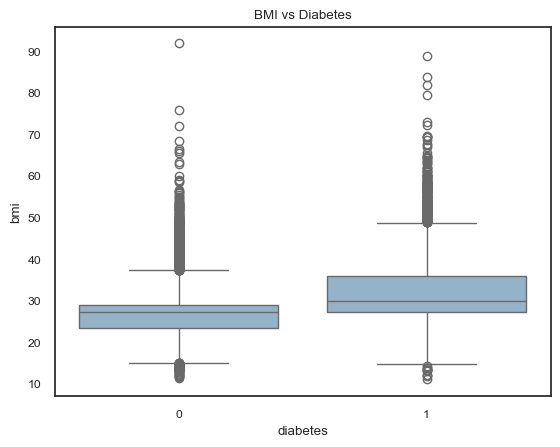

In [86]:
sns.boxplot(x='diabetes', y='bmi', data=df)
plt.title('BMI vs Diabetes')
plt.show()

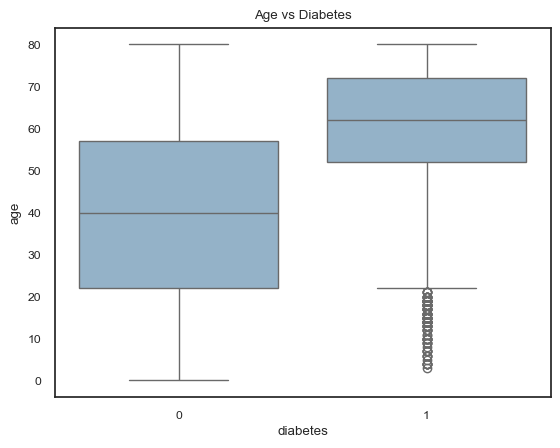

In [87]:
sns.boxplot(x='diabetes', y='age', data=df)
plt.title('Age vs Diabetes')
plt.show()

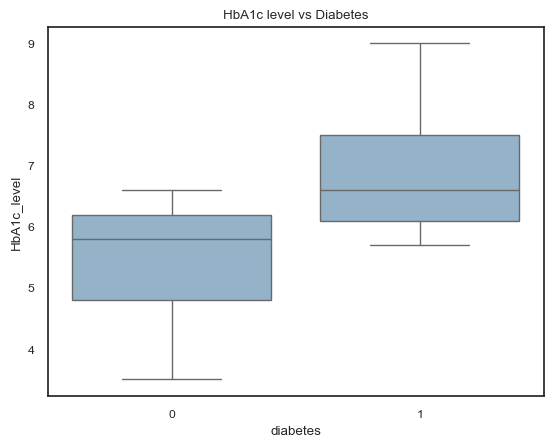

In [88]:
sns.boxplot(x='diabetes', y='HbA1c_level', data=df)
plt.title('HbA1c level vs Diabetes')
plt.show()

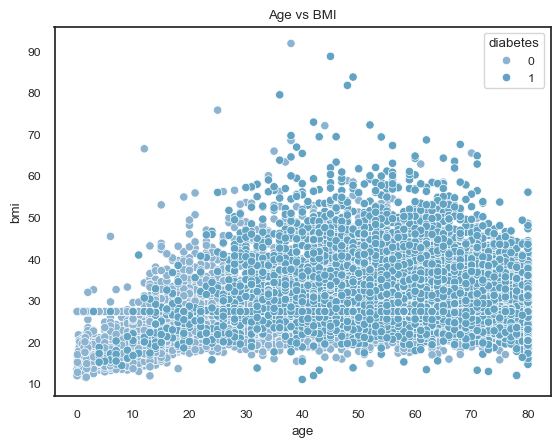

In [89]:
sns.scatterplot(x='age', y='bmi', hue='diabetes', data=df)
plt.title('Age vs BMI')
plt.show()

D:\Temp\ipykernel_13124\982461279.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df, palette='Set2', ax=ax[0])


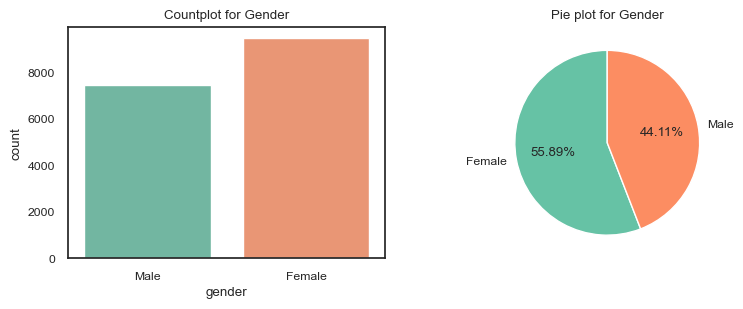

In [90]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
sns.countplot(x='gender', data=df, palette='Set2', ax=ax[0])
ax[0].set_title('Countplot for Gender')
data_counts = df['gender'].value_counts()
ax[1].pie(data_counts, labels=data_counts.index,
          autopct='%1.2f%%', startangle=90,
          colors=sns.color_palette('Set2'))
ax[1].set_title('Pie plot for Gender')

plt.show()


D:\Temp\ipykernel_13124\3033227045.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hypertension', data=df, palette='Set2', ax=ax[0])


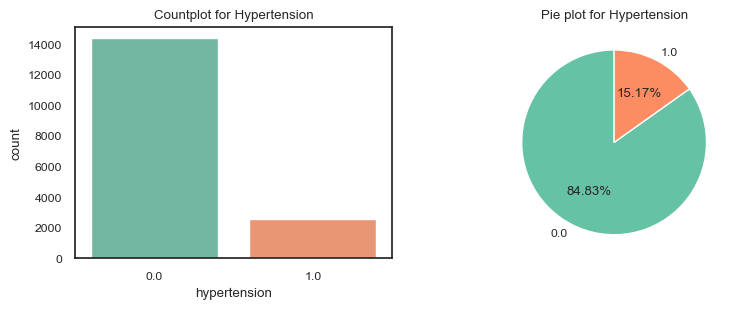

In [91]:

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
sns.countplot(x='hypertension', data=df, palette='Set2', ax=ax[0])
ax[0].set_title('Countplot for Hypertension')
data_counts = df['hypertension'].value_counts()
ax[1].pie(data_counts, labels=data_counts.index,
          autopct='%1.2f%%', startangle=90,
          colors=sns.color_palette('Set2'))
ax[1].set_title('Pie plot for Hypertension')

plt.show()


D:\Temp\ipykernel_13124\1253320652.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['heart_disease'],data=df ,palette='Set2' ,ax=ax[0])


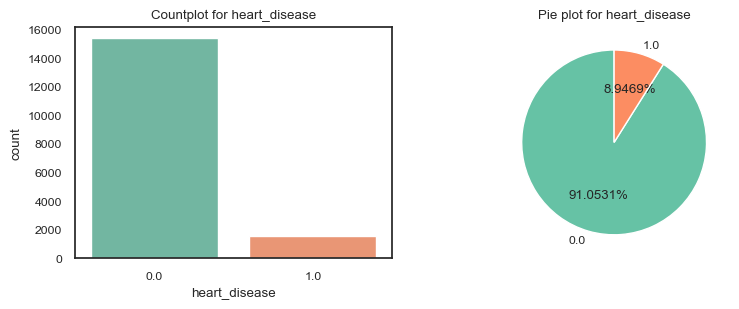

In [92]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
sns.countplot(x=df['heart_disease'],data=df ,palette='Set2' ,ax=ax[0])
ax[0].set_title(f'Countplot for heart_disease')
data_counts = df['heart_disease'].value_counts()
ax[1].pie(data_counts, labels=data_counts.index, autopct='%1.4f%%', startangle=90, colors=sns.color_palette('Set2'))
ax[1].set_title(f'Pie plot for heart_disease')
plt.show()

D:\Temp\ipykernel_13124\3453471555.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['smoking_history'],data=df ,palette='Set2' ,ax=ax[0])


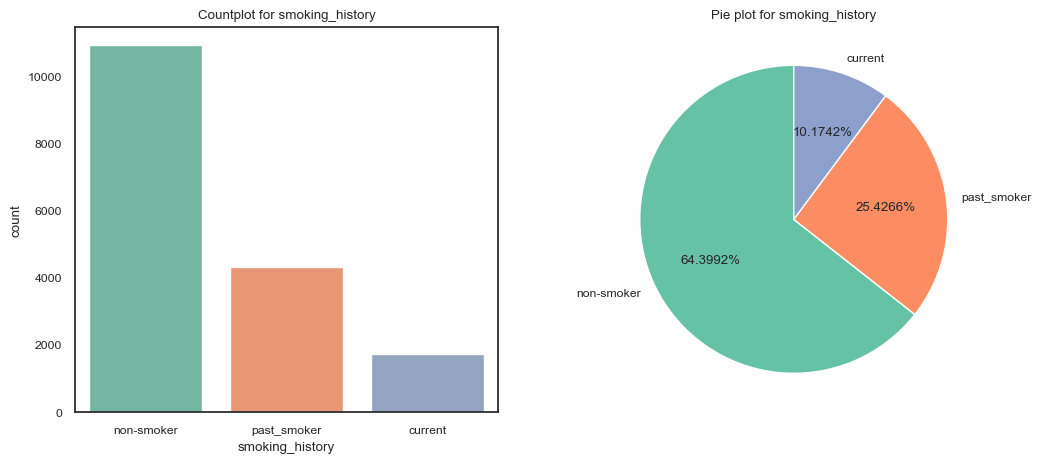

In [93]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=df['smoking_history'],data=df ,palette='Set2' ,ax=ax[0])
ax[0].set_title(f'Countplot for smoking_history')
data_counts = df['smoking_history'].value_counts()
ax[1].pie(data_counts, labels=data_counts.index, autopct='%1.4f%%', startangle=90, colors=sns.color_palette('Set2'))
ax[1].set_title(f'Pie plot for smoking_history')
plt.show()

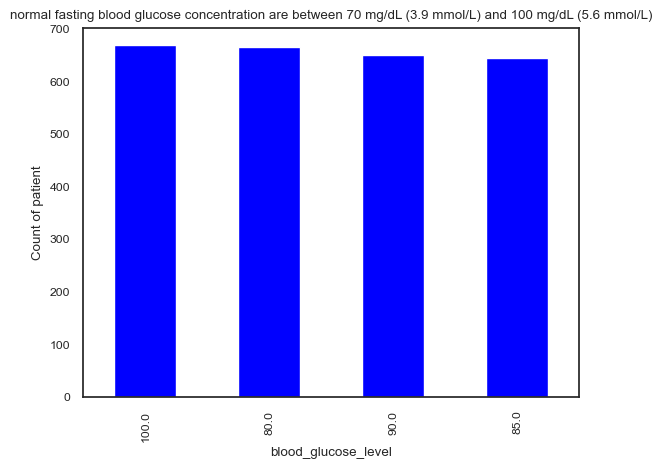

In [94]:
blood_glucose_level_above_70_and_less_than_100 = df[(df['blood_glucose_level'] <= 100) & (df['blood_glucose_level'] >= 70)]

blood_glucose_level_above_70_and_less_than_100['blood_glucose_level'].value_counts().plot(kind='bar', color='blue')

plt.title('normal fasting blood glucose concentration are between 70 mg/dL (3.9 mmol/L) and 100 mg/dL (5.6 mmol/L)')

plt.xlabel('blood_glucose_level')

plt.ylabel('Count of patient')

plt.show()

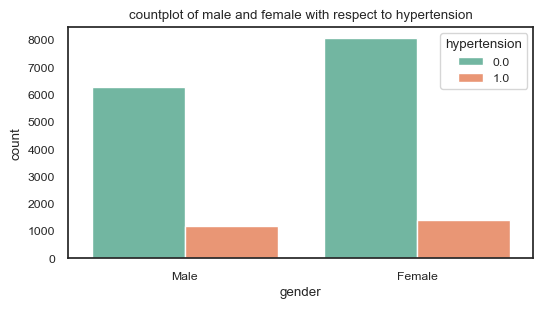

In [95]:
plt.figure(figsize=(6, 3))

sns.countplot(x=df['gender'], hue=df['hypertension'], data=df ,palette='Set2' )

plt.title('countplot of male and female with respect to hypertension')

plt.show()

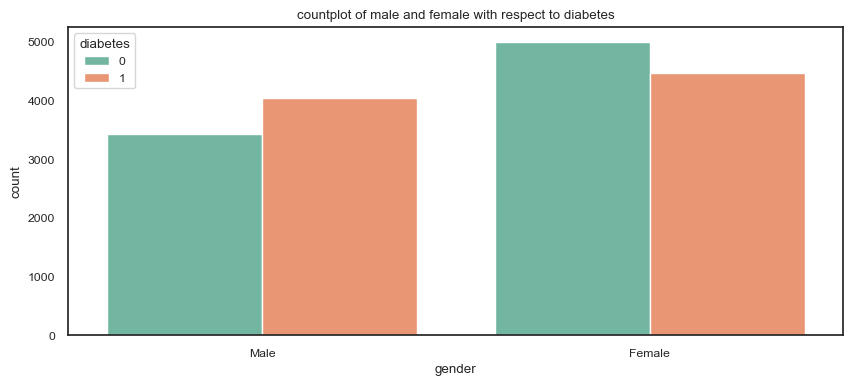

In [96]:
plt.figure(figsize=(10, 4))
sns.countplot(x=df['gender'], hue=df['diabetes'], data=df ,palette='Set2' )
plt.title('countplot of male and female with respect to diabetes')
plt.show()

In [97]:
missing = ['gender', 'hypertension', 'heart_disease', 'smoking_history']
imputer = SimpleImputer(strategy='most_frequent')
df[missing] = imputer.fit_transform(df[missing])
pickle.dump(imputer, open("imputer.pkl", "wb"))

In [98]:
median_cols = ['age','bmi','HbA1c_level','blood_glucose_level']
median_imputer = SimpleImputer(strategy='median')
df[median_cols] = median_imputer.fit_transform(df[median_cols])
pickle.dump(median_imputer, open("median_imputer.pkl","wb"))

In [99]:
df.isna().sum().sort_values(ascending=False)

smoking_history        65
gender                  0
age                     0
hypertension            0
heart_disease           0
bmi                     0
HbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               17000 non-null  object 
 1   age                  17000 non-null  float64
 2   hypertension         17000 non-null  object 
 3   heart_disease        17000 non-null  object 
 4   smoking_history      16935 non-null  object 
 5   bmi                  17000 non-null  float64
 6   HbA1c_level          17000 non-null  float64
 7   blood_glucose_level  17000 non-null  float64
 8   diabetes             17000 non-null  int64  
dtypes: float64(4), int64(1), object(4)
memory usage: 1.2+ MB


In [101]:
numeric_cols = ['hypertension', 'heart_disease']
df[numeric_cols] = df[numeric_cols].astype('float64')

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               17000 non-null  object 
 1   age                  17000 non-null  float64
 2   hypertension         17000 non-null  float64
 3   heart_disease        17000 non-null  float64
 4   smoking_history      16935 non-null  object 
 5   bmi                  17000 non-null  float64
 6   HbA1c_level          17000 non-null  float64
 7   blood_glucose_level  17000 non-null  float64
 8   diabetes             17000 non-null  int64  
dtypes: float64(6), int64(1), object(2)
memory usage: 1.2+ MB


In [103]:
df.duplicated().sum()

np.int64(115)

In [104]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True,inplace=True)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16885 entries, 0 to 16884
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               16885 non-null  object 
 1   age                  16885 non-null  float64
 2   hypertension         16885 non-null  float64
 3   heart_disease        16885 non-null  float64
 4   smoking_history      16836 non-null  object 
 5   bmi                  16885 non-null  float64
 6   HbA1c_level          16885 non-null  float64
 7   blood_glucose_level  16885 non-null  float64
 8   diabetes             16885 non-null  int64  
dtypes: float64(6), int64(1), object(2)
memory usage: 1.2+ MB


In [106]:
lb = LabelEncoder()
df['gender'] = lb.fit_transform(df['gender'])
pickle.dump(lb, open("gender_encoder.pkl", "wb"))

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16885 entries, 0 to 16884
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               16885 non-null  int64  
 1   age                  16885 non-null  float64
 2   hypertension         16885 non-null  float64
 3   heart_disease        16885 non-null  float64
 4   smoking_history      16836 non-null  object 
 5   bmi                  16885 non-null  float64
 6   HbA1c_level          16885 non-null  float64
 7   blood_glucose_level  16885 non-null  float64
 8   diabetes             16885 non-null  int64  
dtypes: float64(6), int64(2), object(1)
memory usage: 1.2+ MB


In [108]:
oh=OneHotEncoder(handle_unknown='ignore')
ohe_encoded = oh.fit_transform(df[['smoking_history']]).toarray()
pickle.dump(oh, open("smoking_encoder.pkl", "wb"))

In [109]:
oh_df = pd.DataFrame(
    ohe_encoded,
    columns=oh.get_feature_names_out(['smoking_history']),
    index=df.index
)
df = pd.concat([df, oh_df], axis=1)

In [110]:
df.drop(['smoking_history'],axis=True,inplace=True)
df.reset_index(drop=True,inplace=True)

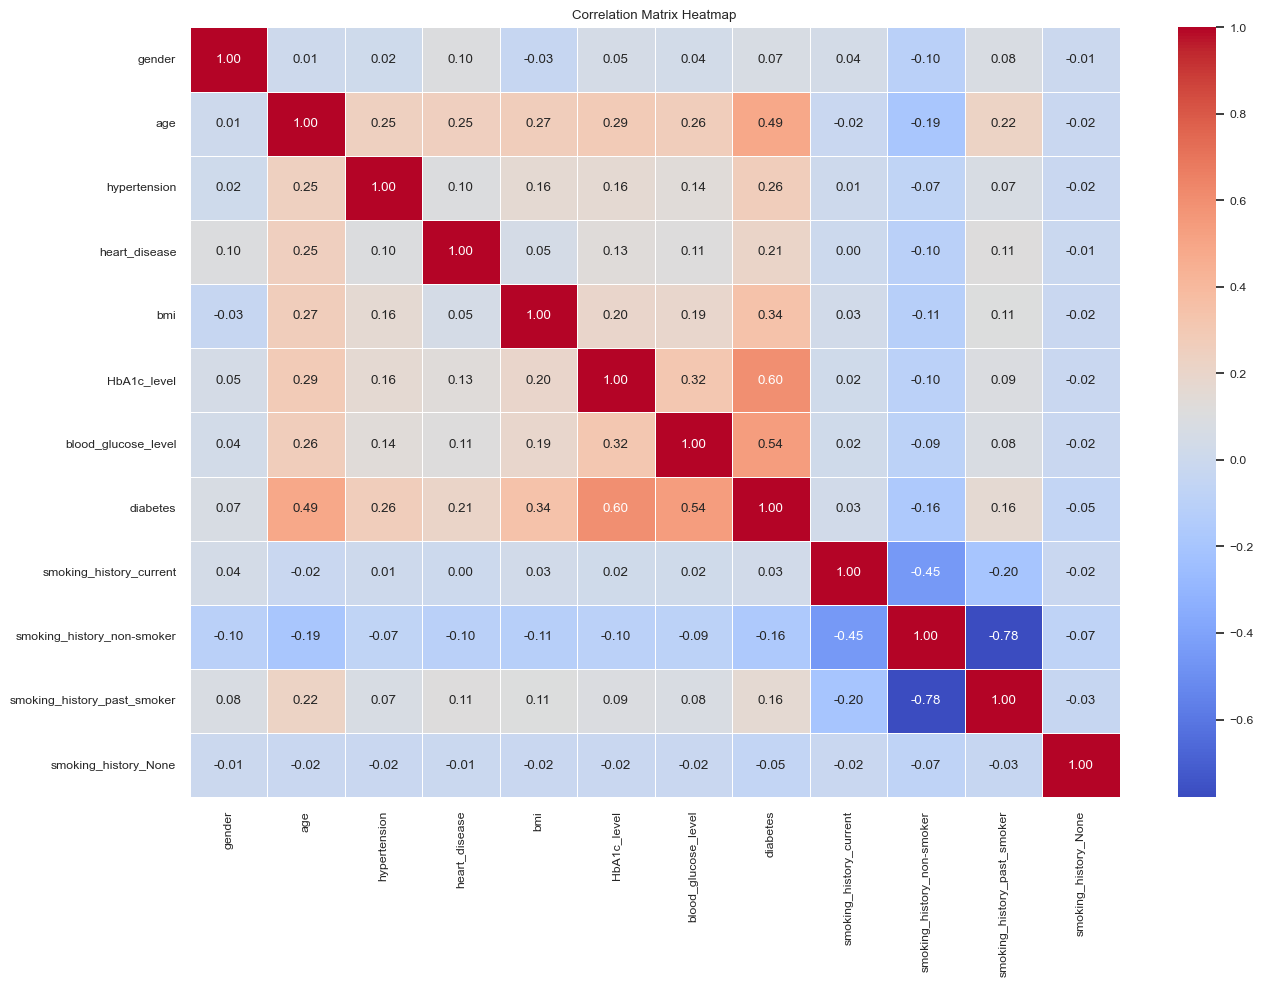

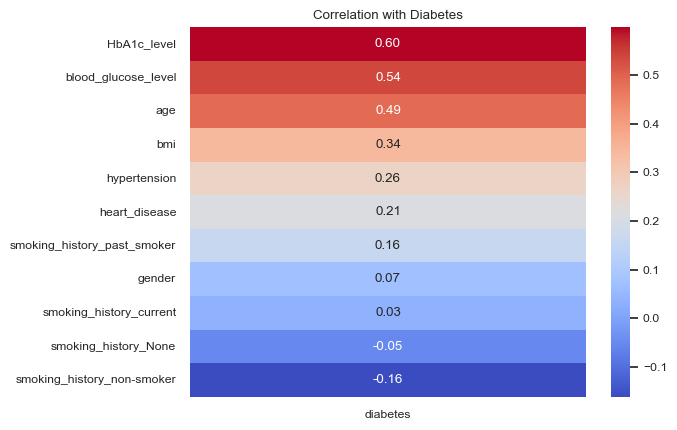

In [111]:

correlation_matrix = df.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title("Correlation Matrix Heatmap")
plt.show()
corr = df.corr()
target_corr = corr['diabetes'].drop('diabetes')
target_corr_sorted = target_corr.sort_values(ascending=False)
sns.set(font_scale=0.8)
sns.set_style("white")
sns.set_palette("PuBuGn_d")
sns.heatmap(target_corr_sorted.to_frame(), cmap="coolwarm", annot=True, fmt='.2f')
plt.title('Correlation with Diabetes')
plt.show()

In [112]:
X= df.drop(columns="diabetes")
y= df['diabetes']

In [113]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=45)

In [114]:
df.describe()

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_current,smoking_history_non-smoker,smoking_history_past_smoker,smoking_history_None
count,16885.000000,16885.000000,16885.000000,16885.000000,16885.000000,16885.000000,16885.000000,16885.000000,16885.000000,16885.000000,16885.000000,16885.000000
mean,0.440272,50.490513,0.152088,0.089665,29.459902,6.170489,163.501036,0.501273,0.101984,0.640450,0.254664,0.002902
std,0.496435,21.444755,0.359116,0.285710,7.470342,1.278946,56.994915,0.500013,0.302636,0.479883,0.435685,0.053793
min,0.000000,0.080000,0.000000,0.000000,10.980000,3.500000,80.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,36.000000,0.000000,0.000000,25.780000,5.700000,130.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,54.000000,0.000000,0.000000,27.320000,6.100000,155.000000,1.000000,0.000000,1.000000,0.000000,0.000000
75%,1.000000,67.000000,0.000000,0.000000,32.890000,6.600000,200.000000,1.000000,0.000000,1.000000,1.000000,0.000000
max,1.000000,80.000000,1.000000,1.000000,91.820000,9.000000,300.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [115]:
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])
pickle.dump(scaler, open("scaler.pkl","wb"))

In [116]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=1, class_weight="balanced"),
    "KNN": KNeighborsClassifier(n_neighbors=5),  
    "SVC": SVC(probability=True, random_state=1, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=1, class_weight="balanced"),
    "Naive Bayes": GaussianNB(), 
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=1, class_weight="balanced"),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=1, class_weight="balanced"),
    "AdaBoost": AdaBoostClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=1),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=1, class_weight="balanced"),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=1, use_label_encoder=False, scale_pos_weight=3),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=1, auto_class_weights="Balanced"),
    "LightGBM": LGBMClassifier(random_state=1, class_weight="balanced")
}


  0%|          | 0/13 [00:00<?, ?it/s]


Logistic Regression Confusion Matrix:
 [[1516  168]
 [ 188 1505]]


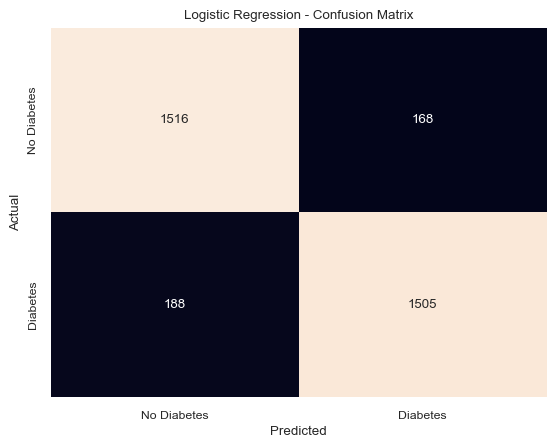


Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.89      0.90      0.89      1684
    Diabetes       0.90      0.89      0.89      1693

    accuracy                           0.89      3377
   macro avg       0.89      0.89      0.89      3377
weighted avg       0.89      0.89      0.89      3377

ROC-AUC: 0.9660638047121513


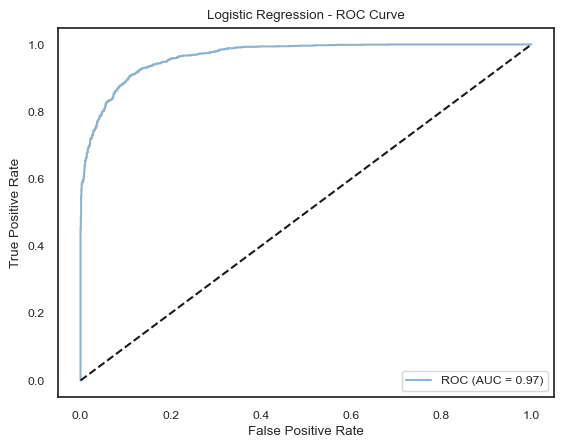

PR AUC: 0.9679299215243827


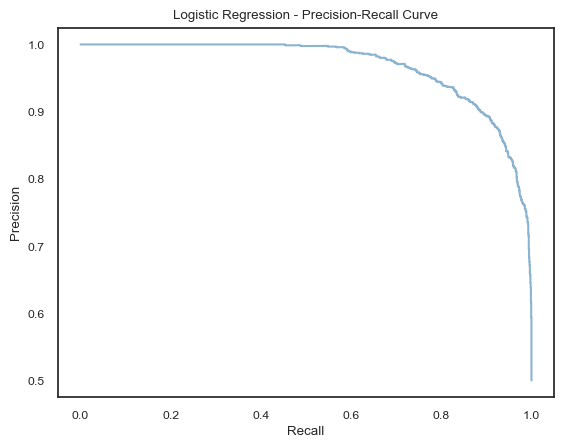

  8%|▊         | 1/13 [00:01<00:13,  1.12s/it]


KNN Confusion Matrix:
 [[1494  190]
 [ 168 1525]]


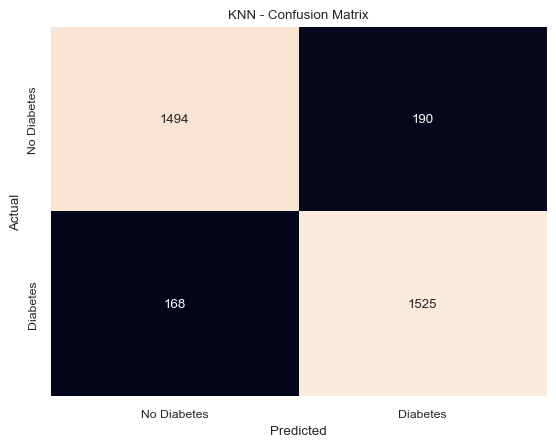


Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.90      0.89      0.89      1684
    Diabetes       0.89      0.90      0.89      1693

    accuracy                           0.89      3377
   macro avg       0.89      0.89      0.89      3377
weighted avg       0.89      0.89      0.89      3377

ROC-AUC: 0.9537041583830583


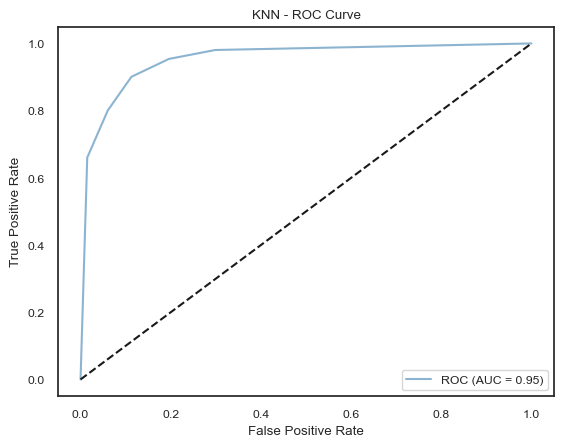

PR AUC: 0.9397418708949488


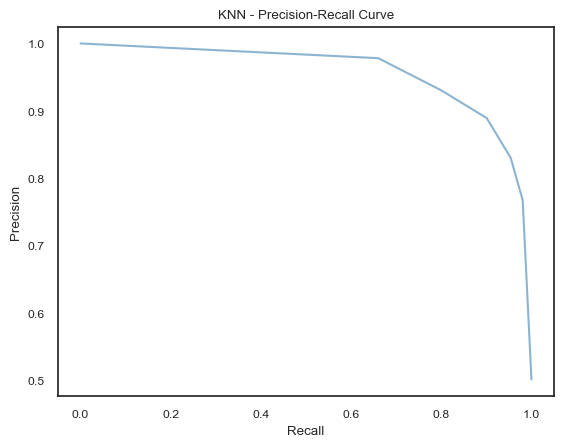

 15%|█▌        | 2/13 [00:10<01:06,  6.02s/it]


SVC Confusion Matrix:
 [[1513  171]
 [ 151 1542]]


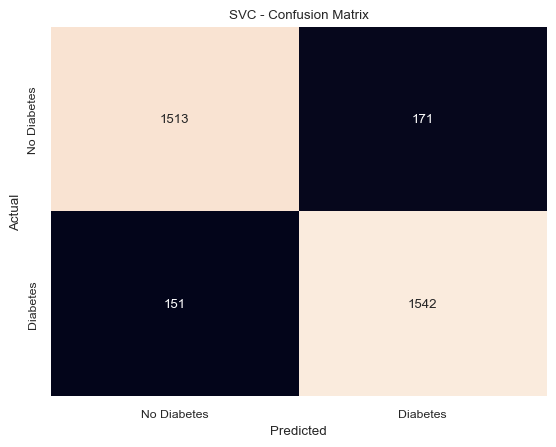


Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.91      0.90      0.90      1684
    Diabetes       0.90      0.91      0.91      1693

    accuracy                           0.90      3377
   macro avg       0.90      0.90      0.90      3377
weighted avg       0.90      0.90      0.90      3377

ROC-AUC: 0.964997165918628


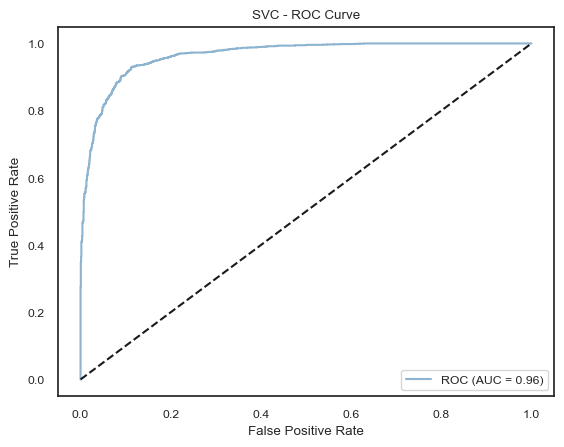

PR AUC: 0.9652206821081869


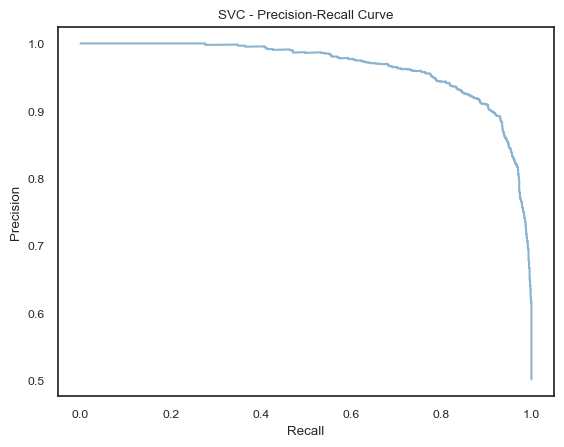

 23%|██▎       | 3/13 [01:39<07:17, 43.76s/it]


Decision Tree Confusion Matrix:
 [[1506  178]
 [ 191 1502]]


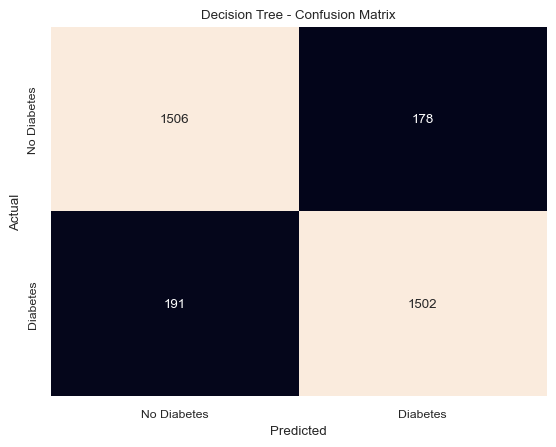


Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.89      0.89      0.89      1684
    Diabetes       0.89      0.89      0.89      1693

    accuracy                           0.89      3377
   macro avg       0.89      0.89      0.89      3377
weighted avg       0.89      0.89      0.89      3377

ROC-AUC: 0.890971521691245


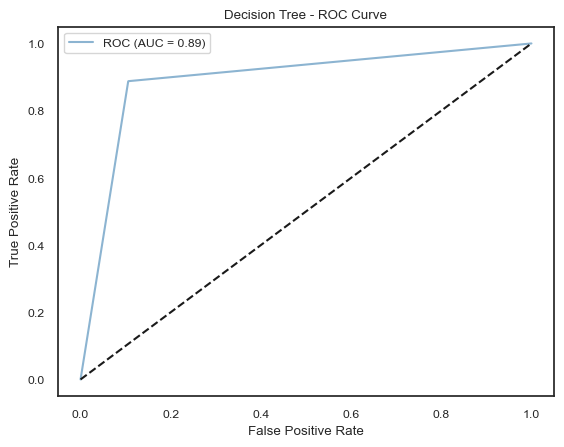

PR AUC: 0.8499741796697238


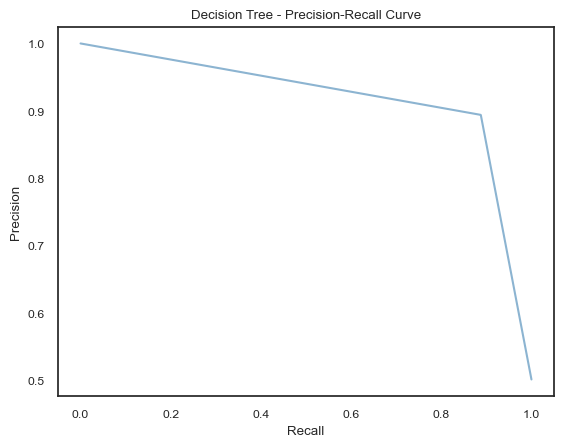

 31%|███       | 4/13 [01:40<04:01, 26.88s/it]


Naive Bayes Confusion Matrix:
 [[  90 1594]
 [   0 1693]]


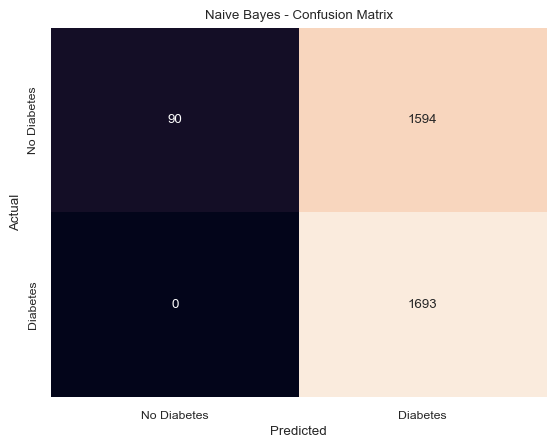


Classification Report:

              precision    recall  f1-score   support

 No Diabetes       1.00      0.05      0.10      1684
    Diabetes       0.52      1.00      0.68      1693

    accuracy                           0.53      3377
   macro avg       0.76      0.53      0.39      3377
weighted avg       0.76      0.53      0.39      3377

ROC-AUC: 0.9245687145476764


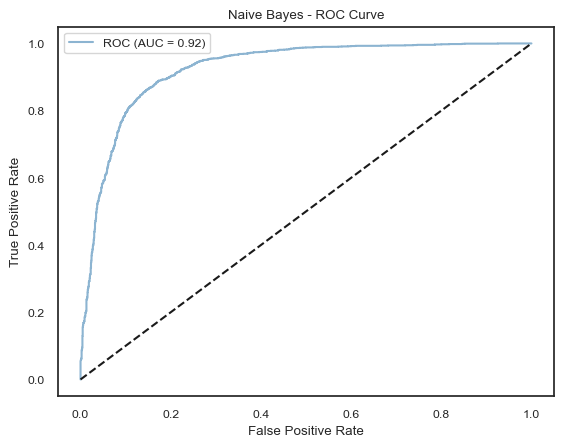

PR AUC: 0.9103048472070203


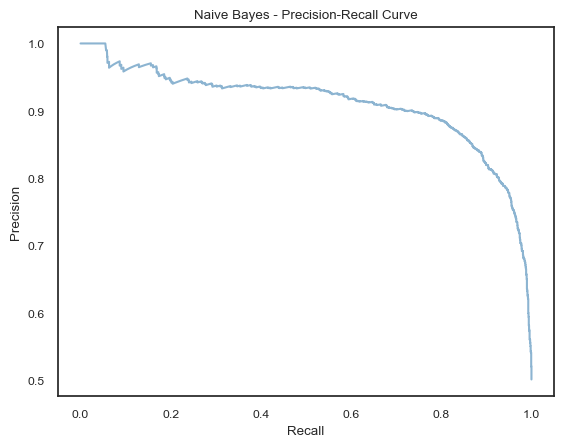

 38%|███▊      | 5/13 [01:41<02:20, 17.54s/it]


Random Forest Confusion Matrix:
 [[1535  149]
 [ 137 1556]]


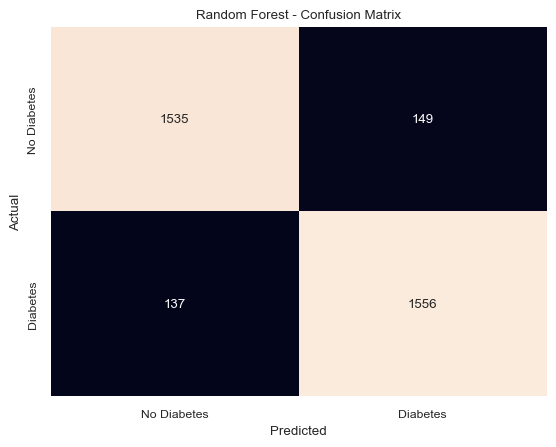


Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.92      0.91      0.91      1684
    Diabetes       0.91      0.92      0.92      1693

    accuracy                           0.92      3377
   macro avg       0.92      0.92      0.92      3377
weighted avg       0.92      0.92      0.92      3377

ROC-AUC: 0.9760572736979011


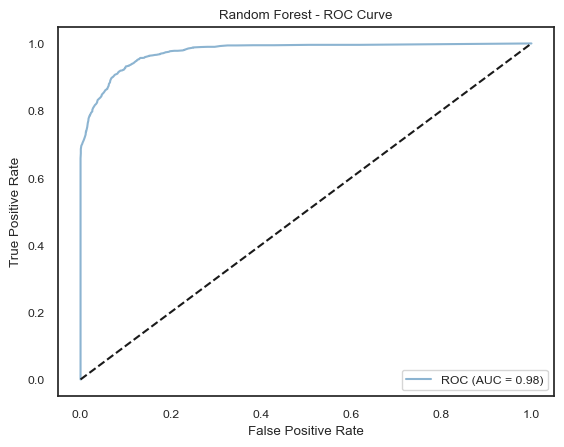

PR AUC: 0.9778338201442526


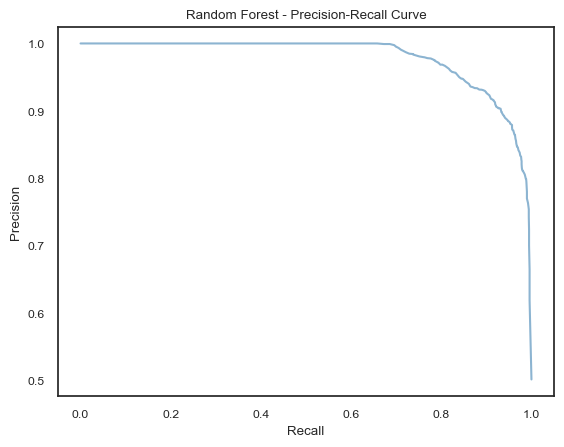

 46%|████▌     | 6/13 [01:44<01:29, 12.73s/it]


Extra Trees Confusion Matrix:
 [[1521  163]
 [ 155 1538]]


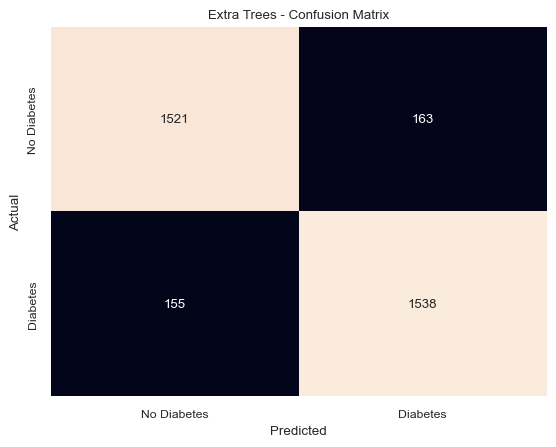


Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.91      0.90      0.91      1684
    Diabetes       0.90      0.91      0.91      1693

    accuracy                           0.91      3377
   macro avg       0.91      0.91      0.91      3377
weighted avg       0.91      0.91      0.91      3377

ROC-AUC: 0.9694745234323812


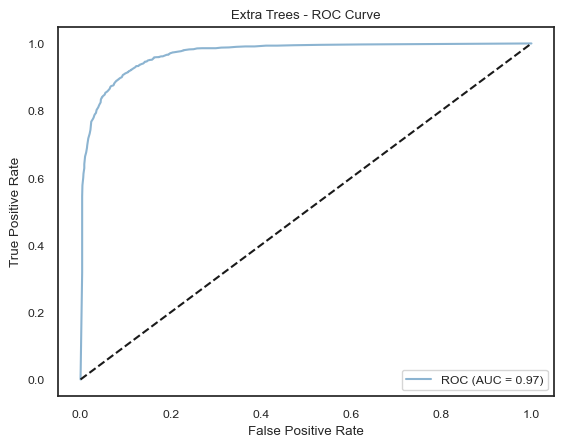

PR AUC: 0.9669412390545813


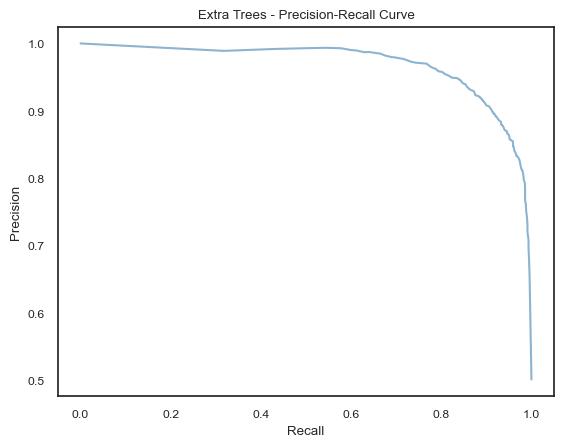

 54%|█████▍    | 7/13 [01:48<00:58,  9.79s/it]


AdaBoost Confusion Matrix:
 [[1476  208]
 [  83 1610]]


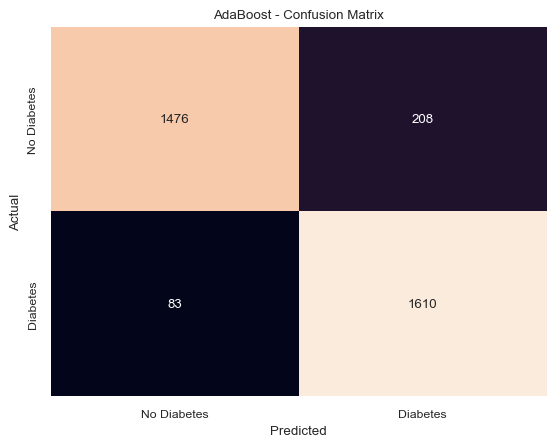


Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.95      0.88      0.91      1684
    Diabetes       0.89      0.95      0.92      1693

    accuracy                           0.91      3377
   macro avg       0.92      0.91      0.91      3377
weighted avg       0.92      0.91      0.91      3377

ROC-AUC: 0.9784718549062579


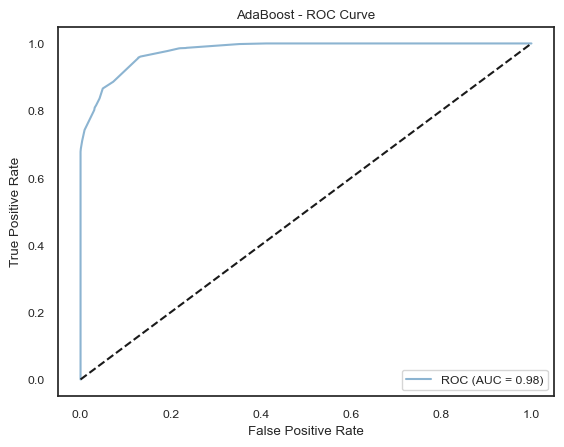

PR AUC: 0.9764207553597242


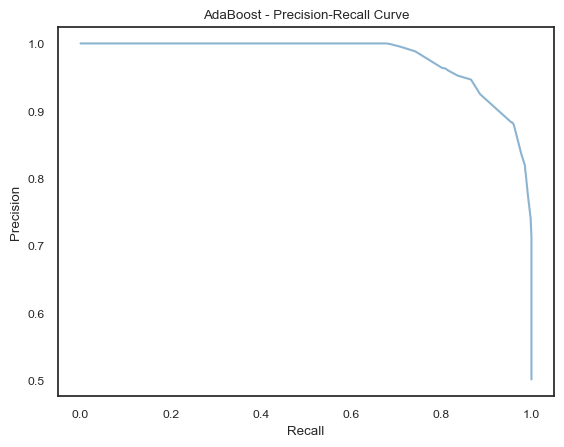

 62%|██████▏   | 8/13 [01:50<00:36,  7.32s/it]


Gradient Boosting Confusion Matrix:
 [[1547  137]
 [ 118 1575]]


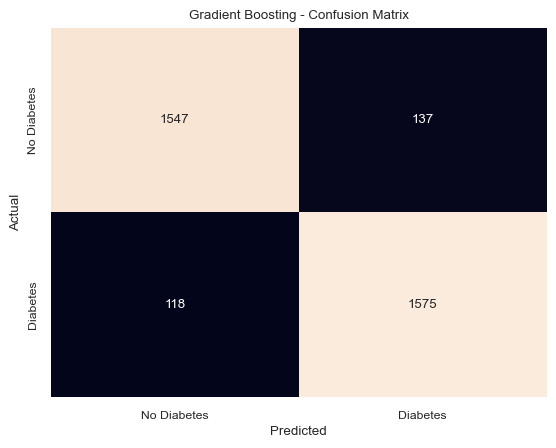


Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.93      0.92      0.92      1684
    Diabetes       0.92      0.93      0.93      1693

    accuracy                           0.92      3377
   macro avg       0.92      0.92      0.92      3377
weighted avg       0.92      0.92      0.92      3377

ROC-AUC: 0.981921682546408


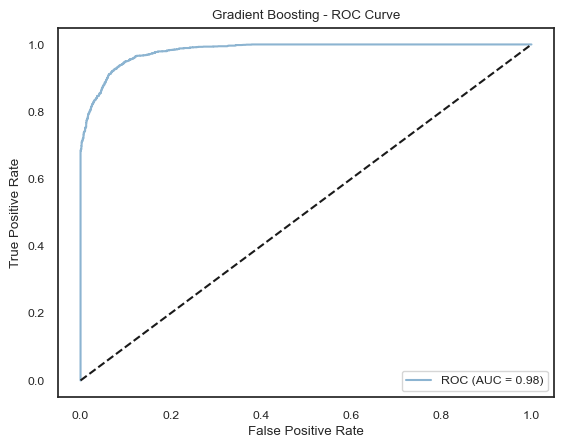

PR AUC: 0.9827283346663023


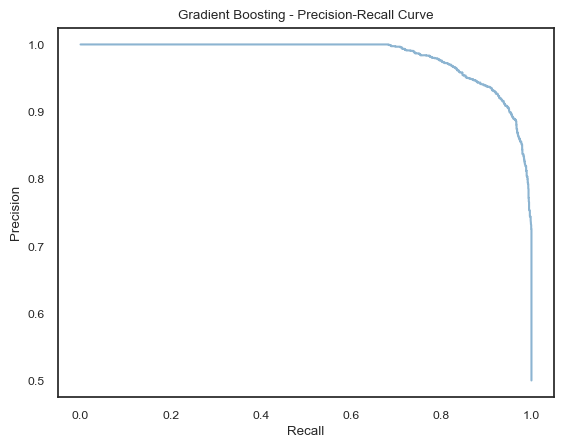

 69%|██████▉   | 9/13 [01:53<00:24,  6.07s/it]


Hist Gradient Boosting Confusion Matrix:
 [[1543  141]
 [ 128 1565]]


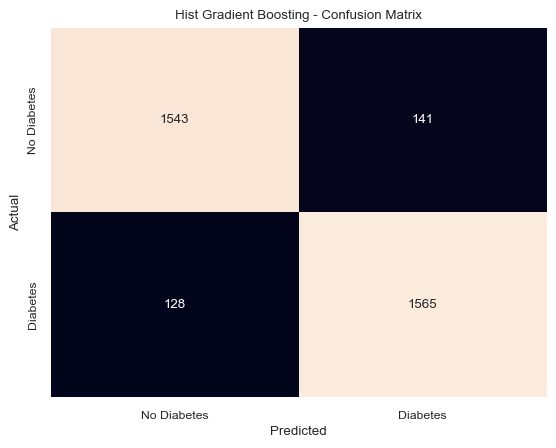


Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.92      0.92      0.92      1684
    Diabetes       0.92      0.92      0.92      1693

    accuracy                           0.92      3377
   macro avg       0.92      0.92      0.92      3377
weighted avg       0.92      0.92      0.92      3377

ROC-AUC: 0.9809190561106021


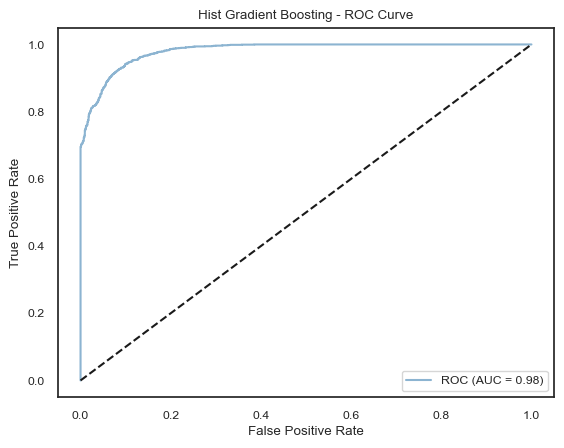

PR AUC: 0.9816440715447715


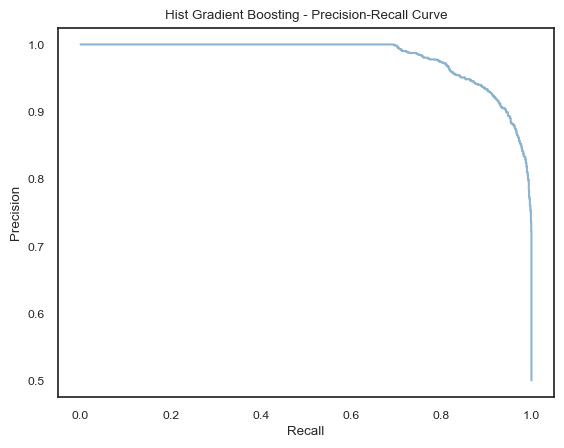

 77%|███████▋  | 10/13 [01:59<00:17,  5.91s/it]d:\saifproject\saif datascience\diabetes prediction_deployment\venv\lib\site-packages\xgboost\training.py:200: UserWarning: [01:57:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Confusion Matrix:
 [[1417  267]
 [  61 1632]]


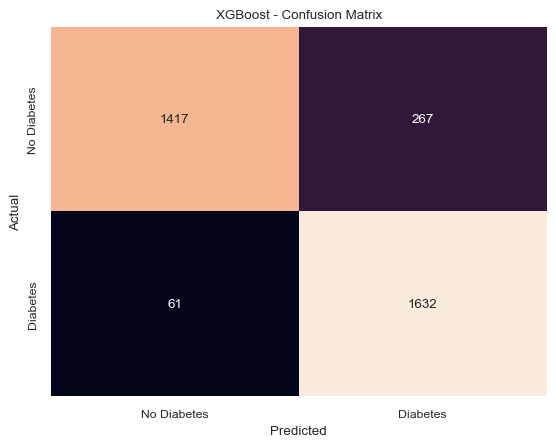


Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.96      0.84      0.90      1684
    Diabetes       0.86      0.96      0.91      1693

    accuracy                           0.90      3377
   macro avg       0.91      0.90      0.90      3377
weighted avg       0.91      0.90      0.90      3377

ROC-AUC: 0.9790816383796349


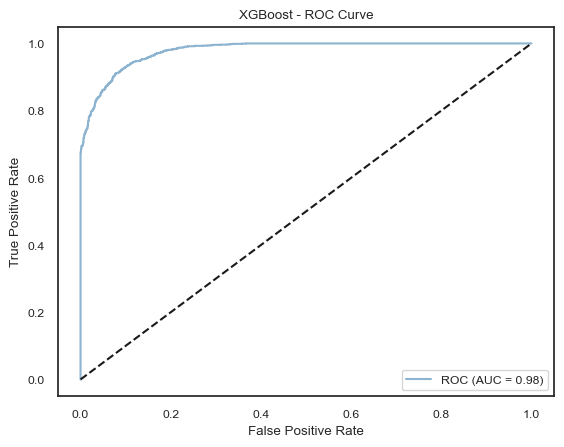

PR AUC: 0.9799812602710415


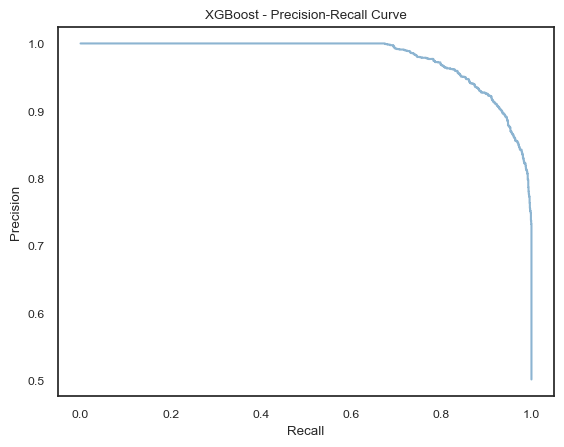

 85%|████████▍ | 11/13 [02:00<00:08,  4.46s/it]


CatBoost Confusion Matrix:
 [[1541  143]
 [ 124 1569]]


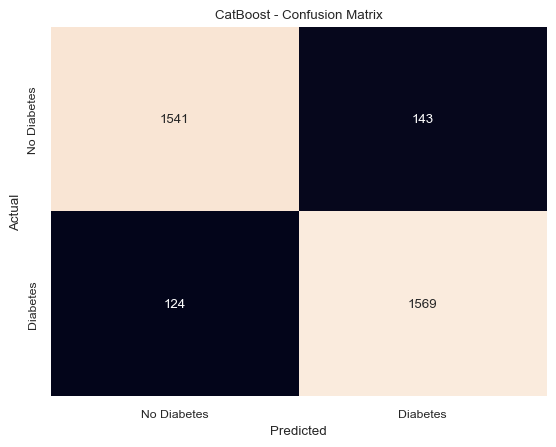


Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.93      0.92      0.92      1684
    Diabetes       0.92      0.93      0.92      1693

    accuracy                           0.92      3377
   macro avg       0.92      0.92      0.92      3377
weighted avg       0.92      0.92      0.92      3377

ROC-AUC: 0.9808378568732787


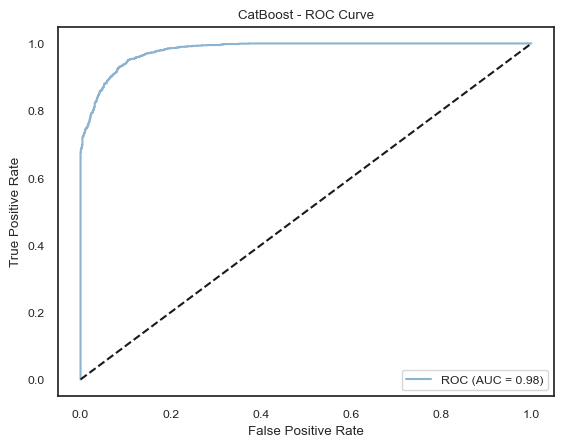

PR AUC: 0.9814802662494942


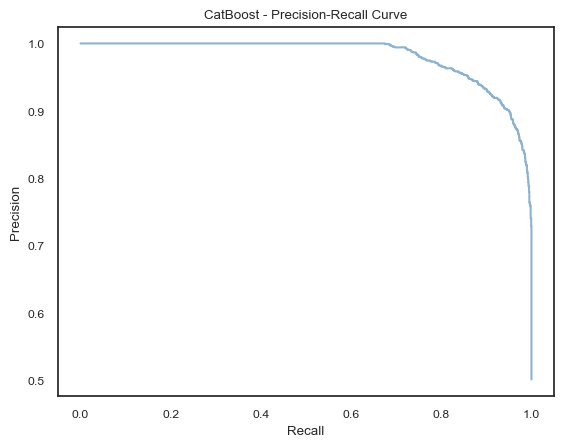

 92%|█████████▏| 12/13 [02:18<00:08,  8.53s/it]

[LightGBM] [Info] Number of positive: 6771, number of negative: 6737
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001715 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 417
[LightGBM] [Info] Number of data points in the train set: 13508, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000

LightGBM Confusion Matrix:
 [[1544  140]
 [ 129 1564]]


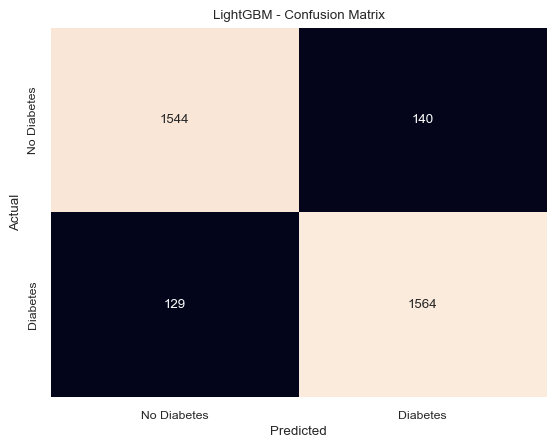


Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.92      0.92      0.92      1684
    Diabetes       0.92      0.92      0.92      1693

    accuracy                           0.92      3377
   macro avg       0.92      0.92      0.92      3377
weighted avg       0.92      0.92      0.92      3377

ROC-AUC: 0.9806084646434318


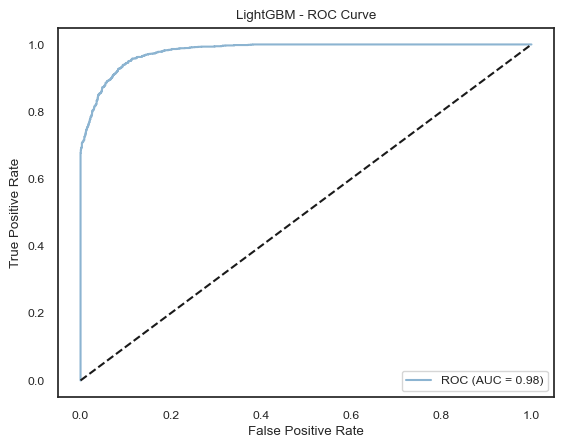

PR AUC: 0.9813021257762056


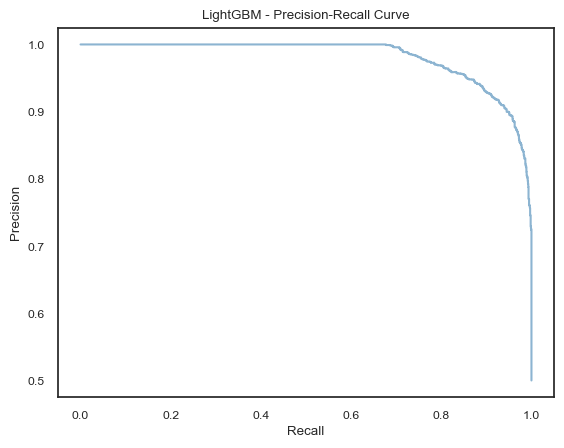

100%|██████████| 13/13 [02:19<00:00, 10.73s/it]


In [117]:
results = {}

for name, model in tqdm(models.items()):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)

    results[name] = {
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train Precision": precision_score(y_train, train_pred),
        "Test Precision": precision_score(y_test, test_pred),
        "Train Recall": recall_score(y_train, train_pred),
        "Test Recall": recall_score(y_test, test_pred),
        "Train F1 Score": f1_score(y_train, train_pred),
        "Test F1 Score": f1_score(y_test, test_pred),
        "Train Balanced Accuracy": balanced_accuracy_score(y_train, train_pred),
        "Test Balanced Accuracy": balanced_accuracy_score(y_test, test_pred)
    }

    cm = confusion_matrix(y_test, test_pred)

    print(f"\n{name} Confusion Matrix:\n", cm)

    plt.figure()
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cbar=False,
        xticklabels=['No Diabetes', 'Diabetes'],
        yticklabels=['No Diabetes', 'Diabetes']
    )

    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'{name} - Confusion Matrix')
    plt.show()

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_test,
            test_pred,
            target_names=['No Diabetes', 'Diabetes'],
            zero_division=0
        )
    )

    if hasattr(model, "predict_proba"):

        y_pred_prob = model.predict_proba(X_test)[:, 1]

        roc_auc = roc_auc_score(y_test, y_pred_prob)
        print("ROC-AUC:", roc_auc)

        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

        plt.figure()
        plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{name} - ROC Curve')
        plt.legend()
        plt.show()

        pr_auc = average_precision_score(y_test, y_pred_prob)
        print("PR AUC:", pr_auc)

        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)

        plt.figure()
        plt.plot(recall_vals, precision_vals)
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'{name} - Precision-Recall Curve')
        plt.show()

In [118]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="Test F1 Score", ascending=False)

In [119]:
results_df

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1 Score,Test F1 Score,Train Balanced Accuracy,Test Balanced Accuracy
Gradient Boosting,0.916198,0.924489,0.904810,0.919977,0.930734,0.930301,0.917589,0.925110,0.916161,0.924474
CatBoost,0.939517,0.920936,0.931324,0.916472,0.949343,0.926757,0.940247,0.921586,0.939493,0.920920
Hist Gradient Boosting,0.931078,0.920344,0.921965,0.917351,0.942254,0.924395,0.931999,0.920859,0.931050,0.920333
LightGBM,0.940628,0.920344,0.931598,0.917840,0.951410,0.923804,0.941400,0.920812,0.940601,0.920334
AdaBoost,0.895840,0.913829,0.867901,0.885589,0.934426,0.950975,0.899936,0.917118,0.895742,0.913730
Random Forest,0.999112,0.915309,0.999261,0.912610,0.998966,0.919079,0.999114,0.915833,0.999112,0.915299
XGBoost,0.938407,0.902872,0.892013,0.859400,0.997932,0.963969,0.942005,0.908686,0.938257,0.902709
Extra Trees,0.999112,0.905834,1.000000,0.904174,0.998228,0.908447,0.999113,0.906305,0.999114,0.905827
SVC,0.895395,0.904649,0.887363,0.900175,0.906365,0.910809,0.896763,0.905461,0.895368,0.904633
KNN,0.916198,0.893989,0.908682,0.889213,0.925860,0.900768,0.917191,0.894953,0.916173,0.893971


d:\saifproject\saif datascience\diabetes prediction_deployment\venv\lib\site-packages\xgboost\training.py:200: UserWarning: [01:57:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


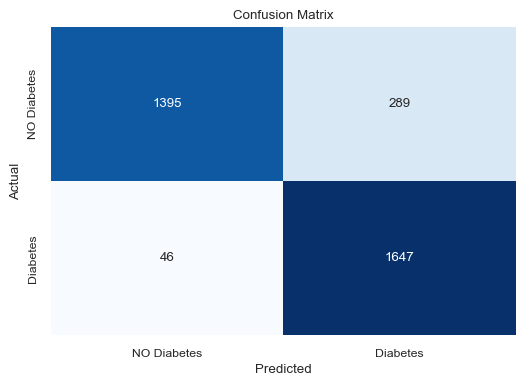


Classification Report:

              precision    recall  f1-score   support

 NO Diabetes       0.97      0.83      0.89      1684
    Diabetes       0.85      0.97      0.91      1693

    accuracy                           0.90      3377
   macro avg       0.91      0.90      0.90      3377
weighted avg       0.91      0.90      0.90      3377

ROC-AUC: 0.9776575826408306


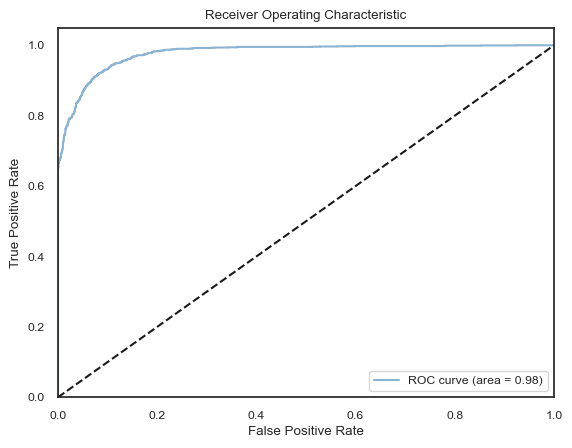

PR AUC: 0.979410117332746


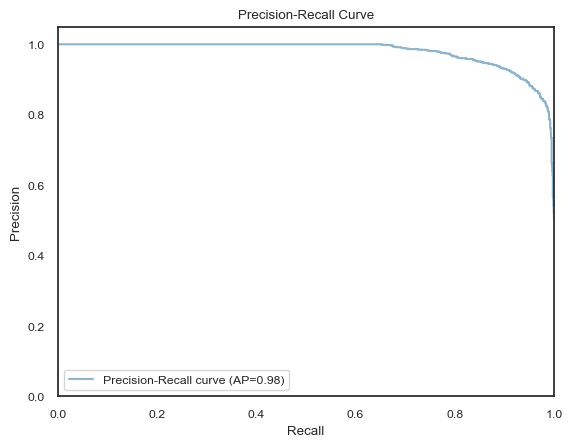

In [120]:
voting_model = VotingClassifier(
    estimators=[
        ("lr", models["Logistic Regression"]),
        ("rf", models["Random Forest"]),
        ("nb", models["Naive Bayes"]),
        ("xgb", models["XGBoost"]),
    ],
    voting="soft"
)

voting_model.fit(X_train, y_train)
voting_train_pred = voting_model.predict(X_train)
voting_test_pred = voting_model.predict(X_test)
results = {}
results["Voting Classifier"] = {
    "Train Accuracy": accuracy_score(y_train, voting_train_pred),
    "Test Accuracy": accuracy_score(y_test, voting_test_pred),
    "Train Precision": precision_score(y_train, voting_train_pred),
    "Test Precision": precision_score(y_test, voting_test_pred),
    "Train Recall": recall_score(y_train, voting_train_pred),
    "Test Recall": recall_score(y_test, voting_test_pred),
    "Train F1 Score": f1_score(y_train, voting_train_pred),
    "Test F1 Score": f1_score(y_test, voting_test_pred),
    "Train Balanced Accuracy": balanced_accuracy_score(y_train, voting_train_pred),
    "Test Balanced Accuracy": balanced_accuracy_score(y_test, voting_test_pred)
}
cm = confusion_matrix(y_test, voting_test_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', cbar=False,
            xticklabels=['NO Diabetes','Diabetes'],
            yticklabels=['NO Diabetes','Diabetes'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()
print("\nClassification Report:\n")
print(classification_report(y_test, voting_test_pred, target_names=['NO Diabetes','Diabetes'], zero_division=0))
y_pred_prob = voting_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC:", roc_auc)

fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_prob)
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'k--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()
pr_auc = average_precision_score(y_test, y_pred_prob)
print("PR AUC:", pr_auc)
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)
plt.figure()
plt.plot(recall_vals, precision_vals, label='Precision-Recall curve (AP={:.2f})'.format(pr_auc))
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

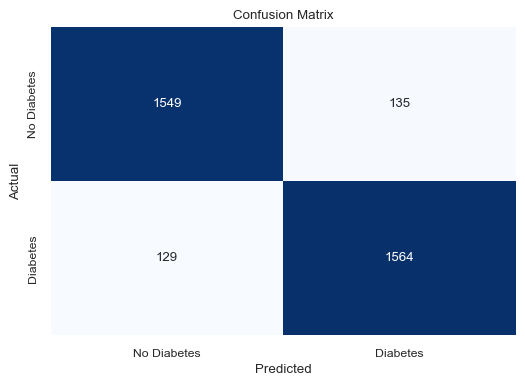


Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.92      0.92      0.92      1684
    Diabetes       0.92      0.92      0.92      1693

    accuracy                           0.92      3377
   macro avg       0.92      0.92      0.92      3377
weighted avg       0.92      0.92      0.92      3377

ROC-AUC: 0.9812128114508111


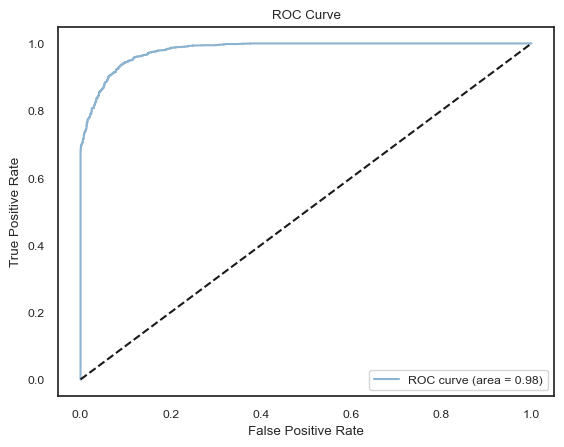

PR AUC: 0.981877244261324


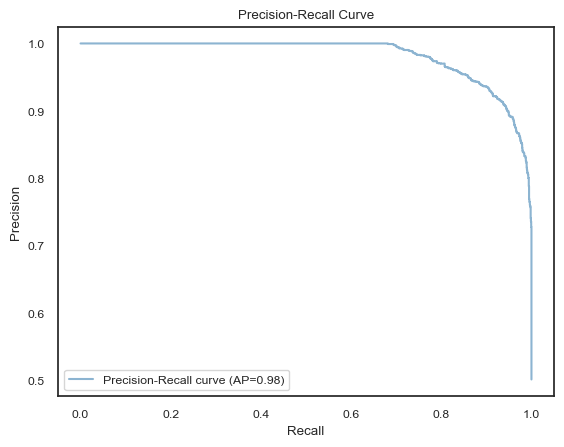

In [121]:
base_models = [
    ("hgb", models["Hist Gradient Boosting"]),
    ("lgbm", models["LightGBM"]),
    ("xgb", models["XGBoost"]),
    ("cat", models["CatBoost"])
]

meta_model = LogisticRegression(max_iter=2000, random_state=1)

stack_auto = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    stack_method="predict_proba",
    n_jobs=-1
)

stack_auto.fit(X_train, y_train)

stack_train_pred = stack_auto.predict(X_train)
stack_test_pred  = stack_auto.predict(X_test)

results["Stacking Classifier"] = {
    "Train Accuracy": accuracy_score(y_train, stack_train_pred),
    "Test Accuracy": accuracy_score(y_test, stack_test_pred),
    "Train Precision": precision_score(y_train, stack_train_pred),
    "Test Precision": precision_score(y_test, stack_test_pred),
    "Train Recall": recall_score(y_train, stack_train_pred),
    "Test Recall": recall_score(y_test, stack_test_pred),
    "Train F1 Score": f1_score(y_train, stack_train_pred),
    "Test F1 Score": f1_score(y_test, stack_test_pred),
    "Train Balanced Accuracy": balanced_accuracy_score(y_train, stack_train_pred),
    "Test Balanced Accuracy": balanced_accuracy_score(y_test, stack_test_pred)
}

cm = confusion_matrix(y_test, stack_test_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', cbar=False,
            xticklabels=['No Diabetes','Diabetes'],
            yticklabels=['No Diabetes','Diabetes'])

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    stack_test_pred,
    target_names=['No Diabetes','Diabetes'],
    zero_division=0
))

y_pred_prob = stack_auto.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC:", roc_auc)

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

pr_auc = average_precision_score(y_test, y_pred_prob)
print("PR AUC:", pr_auc)

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)

plt.figure()
plt.plot(recall_vals, precision_vals,
         label='Precision-Recall curve (AP={:.2f})'.format(pr_auc))

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

In [122]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="Test F1 Score", ascending=False)

In [123]:
results_df

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1 Score,Test F1 Score,Train Balanced Accuracy,Test Balanced Accuracy
Stacking Classifier,0.935594,0.921824,0.928540,0.920541,0.944174,0.923804,0.936292,0.922170,0.935572,0.921819
Voting Classifier,0.933299,0.900800,0.882859,0.850723,0.999557,0.972829,0.937591,0.907688,0.933132,0.900607


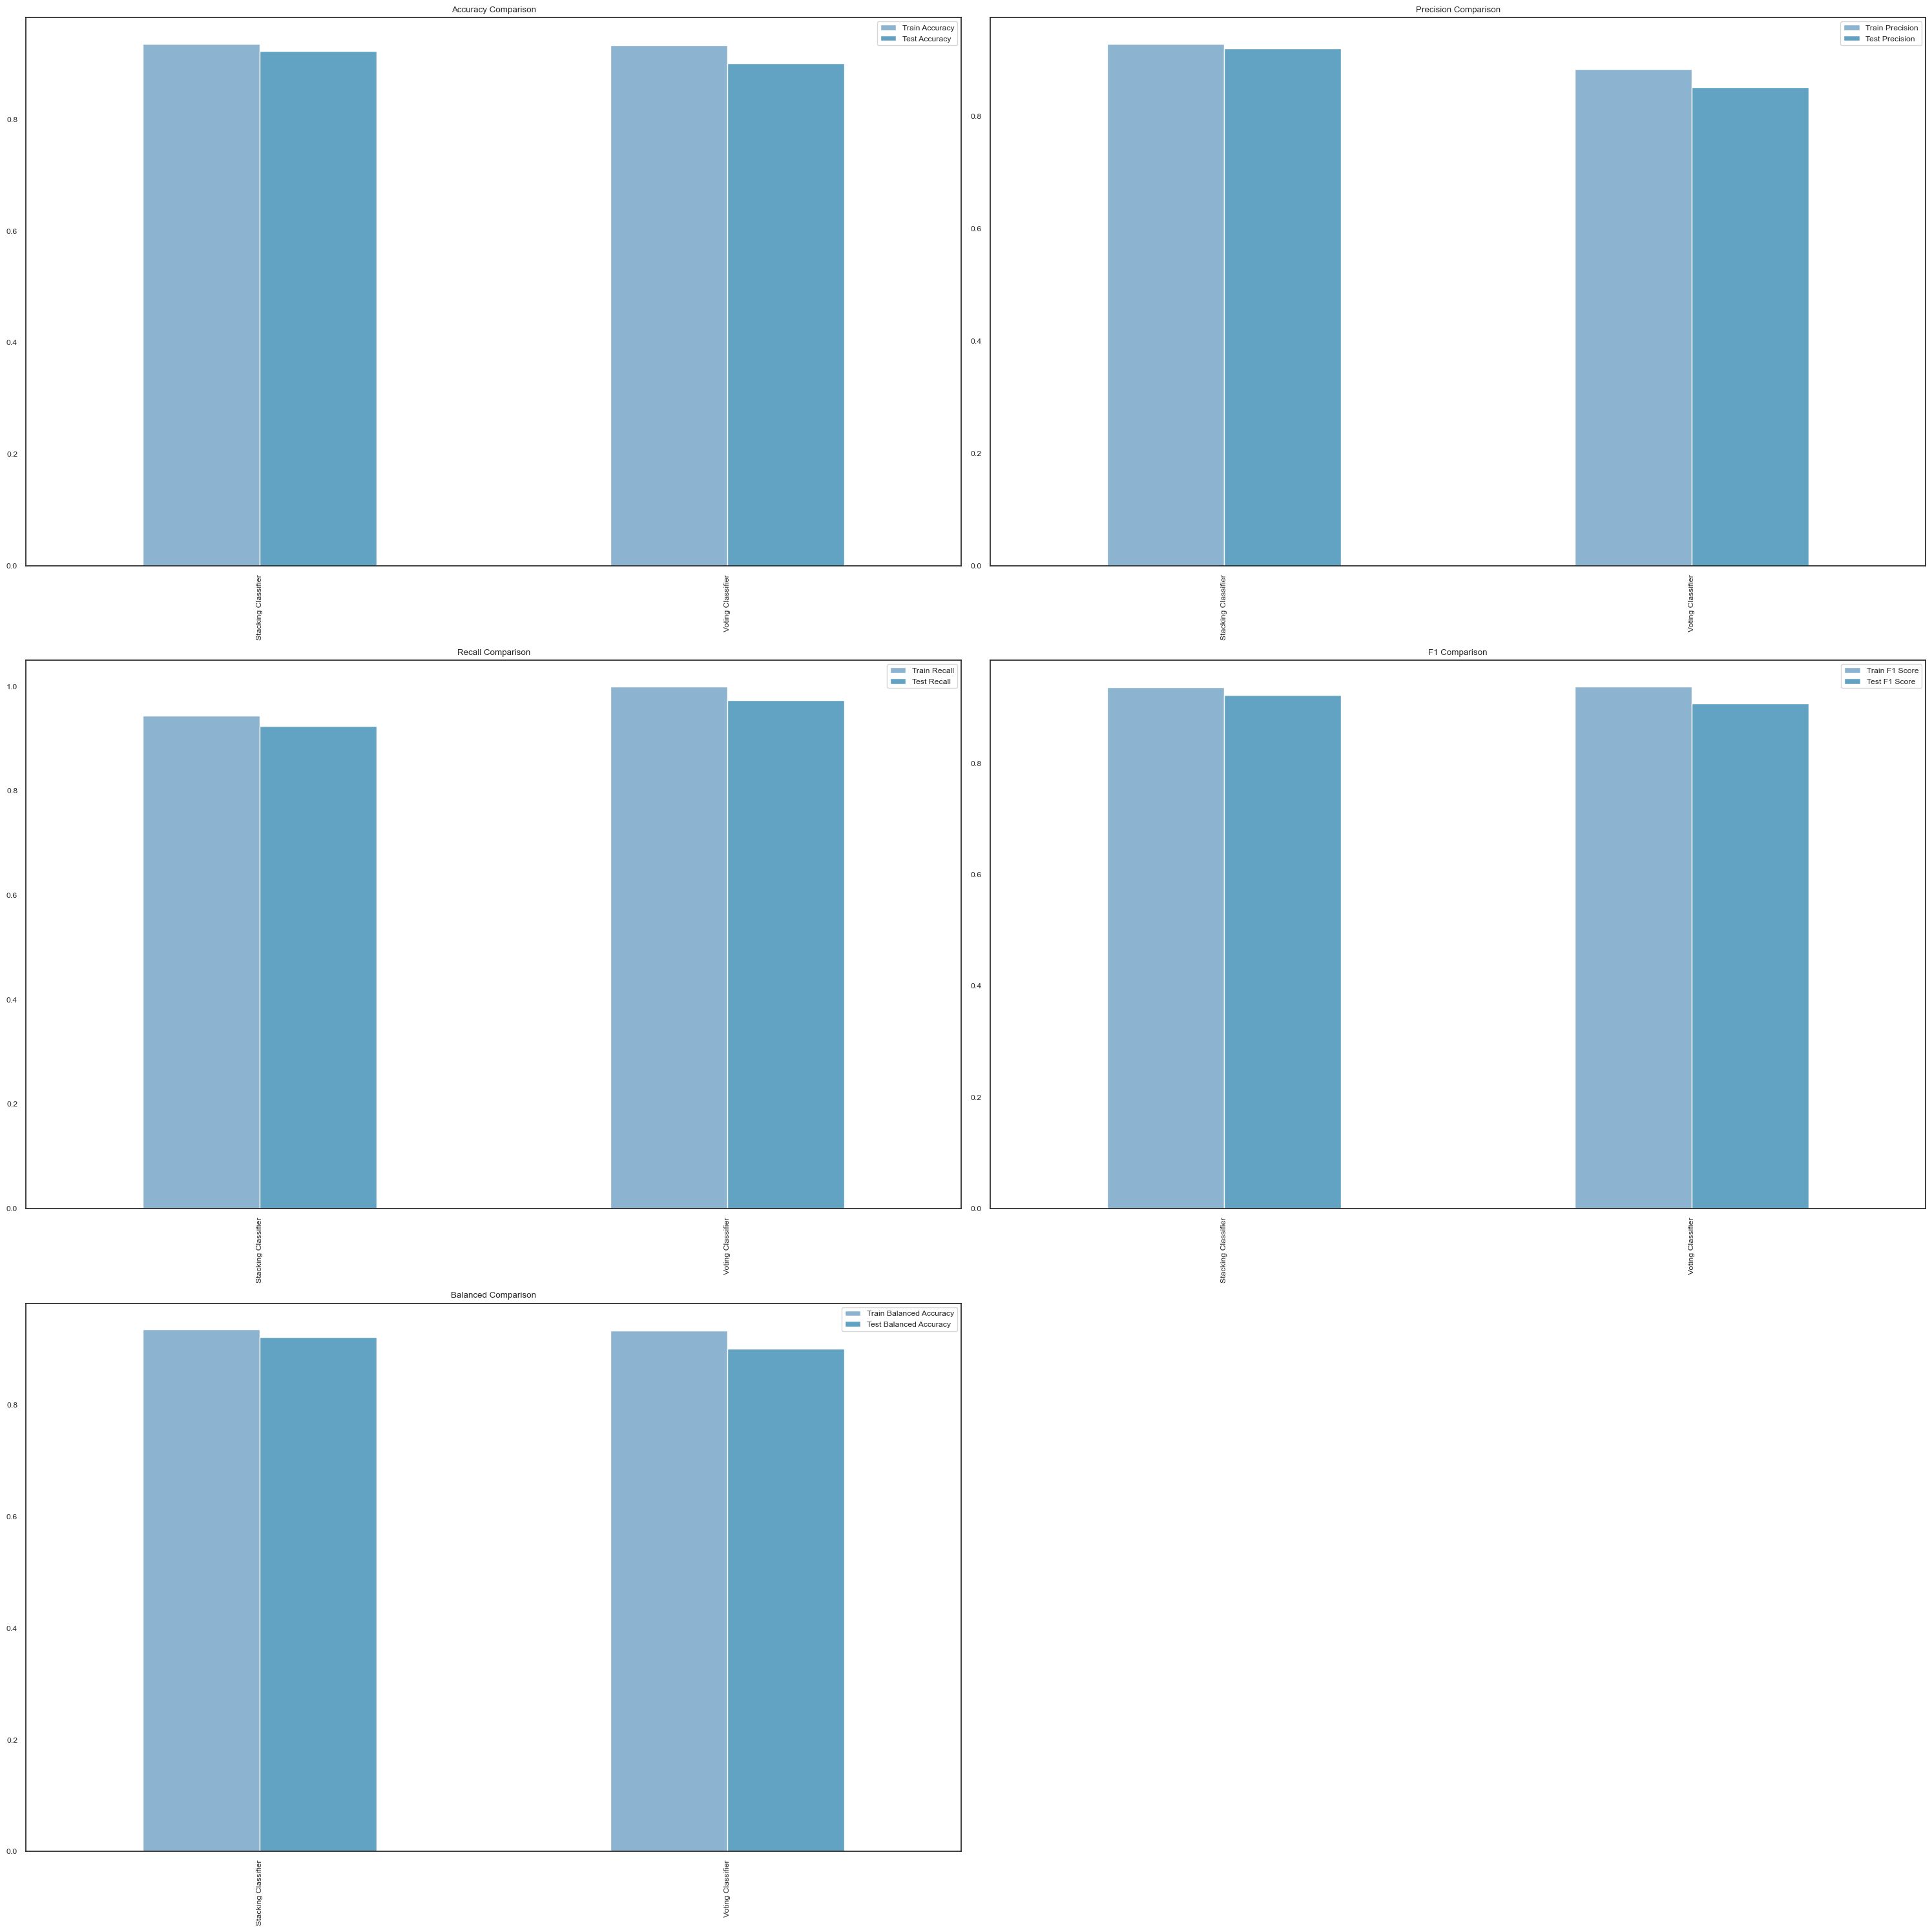

In [124]:
cols = [
    ['Train Accuracy', 'Test Accuracy'],
    ['Train Precision', 'Test Precision'],
    ['Train Recall', 'Test Recall'],
    ['Train F1 Score', 'Test F1 Score'],
    ["Train Balanced Accuracy", "Test Balanced Accuracy"]
]

plt.figure(figsize=(30,30))

for i, col in enumerate(cols):
    ax = plt.subplot(3, 2, i+1)   
    results_df[col].plot.bar(ax=ax)   
    ax.set_title(col[0].split(" ")[1] + ' Comparison')

plt.tight_layout()
plt.show()

<Axes: >

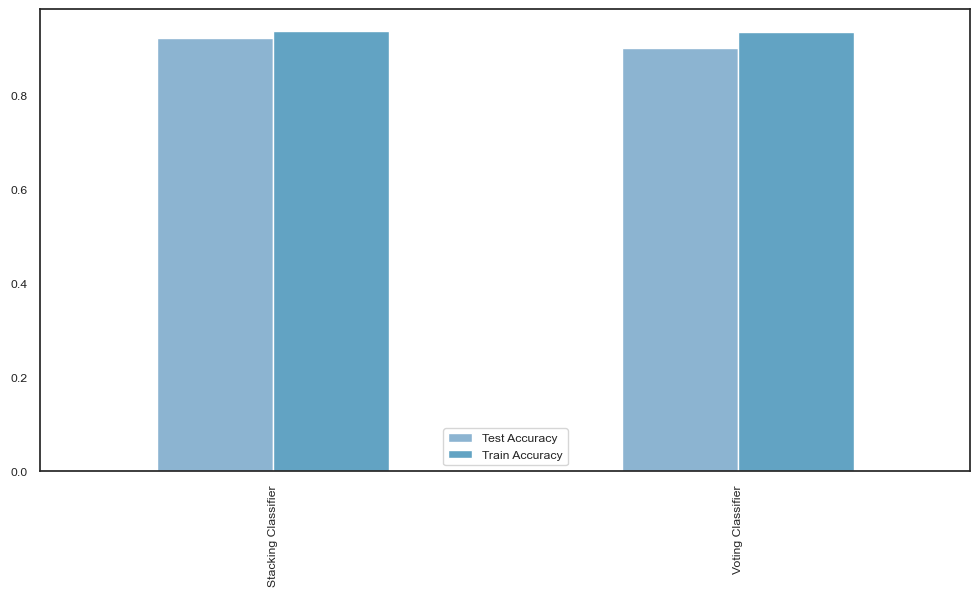

In [125]:
results_df[["Test Accuracy", "Train Accuracy"]].plot.bar(figsize=(12,6))

In [126]:
model = GradientBoostingClassifier()
model.fit(X_train, y_train)
with open("gradient_boosting_model.pkl", "wb") as f:
    pickle.dump(model, f)